# Session 7.3: Applied Statistical Tests
## Practical Lab — Z-Test, T-Test Variations, ANOVA, Chi-Square & Error Types

**Program:** Vishlesan i-Hub IIT Patna x Masai School — AIM (AI & Machine Learning)
**Session ID:** 7.3 | **Week:** 7
**Prerequisites:** Session 7.2 (Statistical Inference & Hypothesis Testing)

---

*Vishlesan i-Hub IIT Patna × Masai School*

## Learning Objectives

By the end of this notebook, you will be able to:

1. Run a **Z-test** manually and explain when it applies (known population sigma)
2. Explain why **z-tests are rare** in practice and how t-tests differ
3. Run all three **t-test variations**: `ttest_1samp`, `ttest_ind`, `ttest_rel`
4. Run **one-way ANOVA** and explain why multiple t-tests inflate Type I error
5. Run both **chi-square tests**: independence (`chi2_contingency`) and goodness of fit (`chisquare`)
6. Explain **Type I and Type II errors** using a diabetes screening example
7. Select the **appropriate test** for any research question

## Prerequisites

You should be comfortable with:
- Hypothesis testing framework (H0, H1, p-values, alpha) from Session 7.2
- Running `ttest_ind` for A/B testing
- NumPy, Pandas, and Matplotlib basics

**Quick self-check:** If p = 0.03 and alpha = 0.05, do you reject or fail to reject H0?

<details>
<summary><font color="#2e7d32"><b>Click for answer</b></font></summary>

Reject H0. Since p (0.03) < alpha (0.05), the result is statistically significant.

</details>

---

## Setup

In [1]:
# ============================================================
#  IMPORTS AND CONFIGURATION
# ============================================================
# Tested with: numpy==1.26.4, scipy==1.12.0, pandas==2.1.4

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)

print("Setup complete!")

Setup complete!


In [2]:
# ============================================================
#  NOTEBOOK FORMATTING HELPERS
# ============================================================

from IPython.display import HTML, display

_BOX_STYLES = {
    "definition": ("#448aff", "#e3f2fd", "#1565c0"),
    "tip":        ("#00c853", "#e8f5e9", "#2e7d32"),
    "warning":    ("#ff9100", "#fff3e0", "#e65100"),
    "danger":     ("#ff1744", "#fce4ec", "#c62828"),
    "math":       ("#7c4dff", "#ede7f6", "#4527a0"),
    "output":     ("#00b8d4", "#e0f7fa", "#006064"),
    "industry":   ("#009688", "#e0f2f1", "#004d40"),
}

def box(kind, title, content):
    """Display a styled callout box."""
    border, bg, title_clr = _BOX_STYLES[kind]
    display(HTML(f"""
    <div style=\"margin:12px 0; color: grey; padding:12px 16px; border-left:4px solid {border};
                background-color:{bg}; border-radius:4px;\">
    <strong style=\"color:{title_clr};\">{title}</strong><br>{content}
    </div>"""))

---

## Business Context: QuickDeliver

QuickDeliver, an Indian e-commerce logistics startup, expanded to 3 cities in 2024. Their data team made four costly mistakes — each time choosing the **wrong statistical test** for the question at hand:

1. Used a z-test when population sigma was unknown
2. Used an independent t-test on paired (before/after) data
3. Ran 6 pairwise t-tests instead of one ANOVA
4. Confused chi-square independence with goodness of fit

**Total cost: Rs. 2.3 crore** in misallocated resources over 6 months.

Today we learn the correct test for every scenario — and the two types of errors every test can make.

---

## Part 1: Z-Test — When Population Sigma Is Known

### The Ruler Analogy

Think of measuring with two types of rulers:
- **Z-test** = a factory-certified ruler where precision is known exactly
- **T-test** = a ruler you found on the ground — you estimate its precision from your measurements

The t-test adds extra uncertainty margin because you are not sure about the ruler itself. In real life, you almost always find the ruler — you rarely have the certified one.

In [3]:
box("definition", "Definition: Z-Test",
    "A parametric hypothesis test used when the population standard deviation (sigma) "
    "is <b>known</b> and the sample size is large (n &ge; 30). "
    "Formula: z = (x&#772; - &mu;<sub>0</sub>) / (&sigma; / &radic;n)")

### Worked Example: Pharmaceutical QC Check

A pharmaceutical company claims their vitamin C tablets contain 500mg on average. From 20 years of manufacturing QC data, the population standard deviation is **known** to be sigma = 15mg. An inspector samples 50 tablets from a new batch.

- **H0:** mu = 500mg (batch meets specification)
- **H1:** mu != 500mg (batch is off-spec)

Since sigma is **known**, this is a z-test scenario.

In [4]:
 # Generate sample: slightly off-spec batch
np.random.seed(42)
sample = np.random.normal(497, 15, 50)

# Known parameters
pop_mean = 500       # claimed mean
pop_sigma = 15       # KNOWN population std dev
n = len(sample)
sample_mean = np.mean(sample)

# Z-test statistic
z_stat = (sample_mean - pop_mean) / (pop_sigma / np.sqrt(n))

# Two-tailed p-value
p_value = 2 * stats.norm.sf(abs(z_stat))

print("=== Z-TEST: Vitamin C Tablet QC ===")
print(f"Claimed mean:    {pop_mean} mg")
print(f"Known sigma:     {pop_sigma} mg")
print(f"Sample size:     {n}")
print(f"Sample mean:     {sample_mean:.2f} mg")
print(f"Z-statistic:     {z_stat:.4f}")
print(f"P-value:         {p_value:.6f}")

=== Z-TEST: Vitamin C Tablet QC ===
Claimed mean:    500 mg
Known sigma:     15 mg
Sample size:     50
Sample mean:     493.62 mg
Z-statistic:     -3.0086
P-value:         0.002625


In [5]:
box("output", "Output Explanation",
    f"The z-statistic of {z_stat:.4f} tells us how many standard errors the sample mean "
    f"is from the claimed 500mg. The p-value of {p_value:.6f} is compared to alpha = 0.05 "
    f"to make the decision.")

In [6]:
# Decision
alpha = 0.05
if p_value < alpha:
    print(f"p ({p_value:.4f}) < alpha ({alpha})")
    print("REJECT H0: batch does NOT meet spec!")
else:
    print(f"p ({p_value:.4f}) >= alpha ({alpha})")
    print("FAIL TO REJECT H0: no evidence batch is off-spec")

p (0.0026) < alpha (0.05)
REJECT H0: batch does NOT meet spec!


### Z-Test vs T-Test: Why Z-Tests Are Rare

| Feature | Z-Test | T-Test |
|---------|--------|--------|
| Population sigma | **KNOWN** | **UNKNOWN** (estimated from sample) |
| Distribution | Standard normal | t-distribution (wider tails) |
| Real-world usage | **Very rare** | **Your default choice** |

In practice, you almost **never** know the true population sigma. You always estimate it from your sample. That makes the t-test the correct default.

In [7]:
box("warning", "Warning",
    "Z-tests are taught for conceptual understanding, but you will almost exclusively "
    "use t-tests in industry. If someone asks 'which test should I use?', the answer "
    "is almost never z-test unless sigma is explicitly given.")

---

## Part 2: T-Test Deep Dive — Three Variations

### The T-Test Family

| Test | Function | When to Use | Example |
|------|----------|-------------|--------|
| One-sample | `ttest_1samp(sample, popmean)` | Sample mean vs a claimed value | "Is avg delivery = 3 days?" |
| Independent | `ttest_ind(a, b)` | Two DIFFERENT groups | "Center A vs Center B" |
| Paired | `ttest_rel(before, after)` | SAME subjects, 2 conditions | "Before vs after heart rate" |

### 2a. One-Sample T-Test: `ttest_1samp`

An e-commerce company claims average delivery time is 3 days. A consumer group tests 40 random deliveries. Population sigma is **unknown** — so we use a t-test, not a z-test.

In [8]:
box("definition", "Definition: One-Sample T-Test",
    "Compares the mean of a single sample to a known or hypothesized population mean. "
    "Use when you have one group and want to test a specific claim about the mean.")

In [9]:
# Sample 40 deliveries (slightly longer than claimed)
np.random.seed(42)
delivery_times = np.random.normal(3.4, 0.8, 40)

# H0: mu = 3.0 (company claim)
# H1: mu != 3.0
claimed = 3.0
t_stat, p_value = stats.ttest_1samp(delivery_times, popmean=claimed)

print("=== ONE-SAMPLE T-TEST: Delivery Claim ===")
print(f"Company claim:   {claimed} days")
print(f"Sample mean:     {np.mean(delivery_times):.2f} days")
print(f"Sample std:      {np.std(delivery_times, ddof=1):.2f} days")
print(f"t-statistic:     {t_stat:.4f}")
print(f"P-value:         {p_value:.6f}")
print(f"Decision:        {'REJECT H0' if p_value < 0.05 else 'Fail to reject H0'}")

=== ONE-SAMPLE T-TEST: Delivery Claim ===
Company claim:   3.0 days
Sample mean:     3.23 days
Sample std:      0.76 days
t-statistic:     1.8676
P-value:         0.069341
Decision:        Fail to reject H0


In [10]:
delivery_times

array([3.79737132, 3.28938856, 3.91815083, 4.61842389, 3.2126773 ,
       3.21269043, 4.66337025, 4.01394778, 3.02442049, 3.83404803,
       3.02926585, 3.0274162 , 3.59356982, 1.8693758 , 2.02006573,
       2.95016998, 2.5897351 , 3.65139787, 2.67358074, 2.27015704,
       4.57251902, 3.21937896, 3.45402256, 2.26020145, 2.96449382,
       3.48873807, 2.47920514, 3.70055841, 2.91948905, 3.166645  ,
       2.91863471, 4.88182255, 3.38920222, 2.55383126, 4.05803593,
       2.42332508, 3.56709088, 1.8322639 , 2.33745116, 3.55748899])

#### Directional Tests: The `alternative` Parameter

The test above used the **default two-tailed** behaviour — it checks whether the sample mean is *different* from the claimed value in **either direction**.

But many business questions are **directional**:
- "Is our new battery **better** than the old one?" → we only care about *greater*
- "Are delivery times **exceeding** the SLA?" → we only care about *less* (shorter is fine)

SciPy's `ttest_1samp` accepts an `alternative` parameter to handle this.

In [11]:
box("definition", "The alternative Parameter in ttest_1samp",
    "<code>alternative='two-sided'</code> (default) — H₁: μ ≠ μ₀ — reject if mean is significantly higher OR lower.<br>"
    "<code>alternative='greater'</code> — H₁: μ &gt; μ₀ — reject only if sample mean is significantly HIGHER.<br>"
    "<code>alternative='less'</code> — H₁: μ &lt; μ₀ — reject only if sample mean is significantly LOWER.")

#### Scenario: QuickDeliver Scanner Batteries

QuickDeliver's warehouse scanners use rechargeable batteries. The manufacturer claims an average battery life of **8 hours**. Three different teams ask three different questions:

| Team | Question | H₀ | H₁ | Tail | `alternative=` |
|------|----------|----|----|------|----------------|
| Quality Audit | Is battery life **different** from 8h? | μ = 8 | μ ≠ 8 | Two-tailed | `'two-sided'` |
| Procurement | Does the new vendor's battery last **more** than 8h? | μ = 8 | μ > 8 | Right-tailed | `'greater'` |
| Safety | Are aging batteries falling **below** 8h? | μ = 8 | μ < 8 | Left-tailed | `'less'` |

In [12]:
# Three battery-life datasets for three business questions
np.random.seed(99)
battery_audit      = np.random.normal(8.3, 0.9, 40)   # mild difference
battery_new_vendor = np.random.normal(8.6, 0.7, 40)   # clear improvement
battery_aging      = np.random.normal(7.5, 0.8, 40)   # decline

print("=== Battery Life Samples (hours) ===")
print(f"Audit sample mean:      {np.mean(battery_audit):.2f}")
print(f"New vendor sample mean: {np.mean(battery_new_vendor):.2f}")
print(f"Aging sample mean:      {np.mean(battery_aging):.2f}")
print(f"Claimed mean:           8.00")

=== Battery Life Samples (hours) ===
Audit sample mean:      8.31
New vendor sample mean: 8.66
Aging sample mean:      7.71
Claimed mean:           8.00


**Question 1 (Two-Tailed): Is battery life *different* from 8 hours?**

The quality audit team does not assume a direction — batteries could be lasting longer *or* shorter than claimed. Any deviation matters.

- **H₀:** μ = 8 &nbsp;&nbsp;|&nbsp;&nbsp; **H₁:** μ ≠ 8
- The p-value measures the probability of seeing a result **this extreme in either direction**.

In [13]:
# Two-tailed: Is battery life DIFFERENT from 8 hours?
t_stat, p_val = stats.ttest_1samp(battery_audit, 8.0, alternative='two-sided')

print("=== TWO-TAILED TEST (Quality Audit) ===")
print(f"H0: mu = 8   |   H1: mu != 8")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.6f}")
print(f"Decision:    {'REJECT H0' if p_val < 0.05 else 'Fail to reject H0'}")

=== TWO-TAILED TEST (Quality Audit) ===
H0: mu = 8   |   H1: mu != 8
t-statistic: 2.2683
p-value:     0.028925
Decision:    REJECT H0


**Question 2 (Right-Tailed): Does the new vendor exceed 8 hours?**

The procurement team is evaluating a new battery vendor who claims their product lasts **more** than 8 hours. They only care about proving the battery is *better* — if it's the same or worse, they won't switch.

- **H₀:** μ = 8 &nbsp;&nbsp;|&nbsp;&nbsp; **H₁:** μ > 8
- The p-value measures the probability of seeing a mean **this high or higher** under H₀.

In [14]:
# Right-tailed: Does new vendor EXCEED 8 hours?
t_stat, p_val = stats.ttest_1samp(battery_new_vendor, 8.0, alternative='greater')

print("=== RIGHT-TAILED TEST (Procurement) ===")
print(f"H0: mu <= 8   |   H1: mu > 8")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.6f}")
print(f"Decision:    {'REJECT H0 — new vendor is better' if p_val < 0.05 else 'Fail to reject H0'}")

=== RIGHT-TAILED TEST (Procurement) ===
H0: mu <= 8   |   H1: mu > 8
t-statistic: 5.6074
p-value:     0.000001
Decision:    REJECT H0 — new vendor is better


**Question 3 (Left-Tailed): Are aging batteries falling below 8 hours?**

The safety team is concerned that older batteries are degrading. They only care about **underperformance** — if batteries still meet or exceed 8 hours, there's no problem.

- **H₀:** μ = 8 &nbsp;&nbsp;|&nbsp;&nbsp; **H₁:** μ < 8
- The p-value measures the probability of seeing a mean **this low or lower** under H₀.

In [15]:
# Left-tailed: Are aging batteries BELOW 8 hours?
t_stat, p_val = stats.ttest_1samp(battery_aging, 8.0, alternative='less')

print("=== LEFT-TAILED TEST (Safety) ===")
print(f"H0: mu >= 8   |   H1: mu < 8")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.6f}")
print(f"Decision:    {'REJECT H0 — batteries are degrading' if p_val < 0.05 else 'Fail to reject H0'}")

=== LEFT-TAILED TEST (Safety) ===
H0: mu >= 8   |   H1: mu < 8
t-statistic: -2.4250
p-value:     0.010021
Decision:    REJECT H0 — batteries are degrading


#### Key Insight: Same Statistic, Different P-Values

The t-statistic depends only on the data — it does not change with the `alternative` parameter. But the **p-value does**, because it measures the area in different regions of the distribution.

**Rule of thumb:** For the same data, `p_two_sided = 2 × p_one_sided` (when the one-sided direction matches the data). Let's verify this.

In [16]:
# Same data, three alternatives — watch the p-values
data = battery_new_vendor
t, p_two   = stats.ttest_1samp(data, 8.0, alternative='two-sided')
_, p_right = stats.ttest_1samp(data, 8.0, alternative='greater')
_, p_left  = stats.ttest_1samp(data, 8.0, alternative='less')

print("=== SAME DATA, THREE ALTERNATIVES ===")
print(f"t-statistic (same for all): {t:.4f}\n")
print(f"{'Alternative':<15} {'P-value':>10}  Relationship")
print("-" * 50)
print(f"{'two-sided':<15} {p_two:>10.6f}  = 2 x p_greater")
print(f"{'greater':<15} {p_right:>10.6f}  (right tail only)")
print(f"{'less':<15} {p_left:>10.6f}  (left tail only)")
print(f"\nVerify: 2 x p_greater = {2*p_right:.6f} ≈ p_two_sided = {p_two:.6f}")

=== SAME DATA, THREE ALTERNATIVES ===
t-statistic (same for all): 5.6074

Alternative        P-value  Relationship
--------------------------------------------------
two-sided         0.000002  = 2 x p_greater
greater           0.000001  (right tail only)
less              0.999999  (left tail only)

Verify: 2 x p_greater = 0.000002 ≈ p_two_sided = 0.000002


#### Visualising the Three Tail Types

The diagram below shows the t-distribution under H₀. The **shaded red region** is the area where we reject H₀ at α = 0.05. The **blue dashed line** marks the observed t-statistic.

In [17]:
def plot_tail(ax, x, y, df, t_obs, tail, title):
    ax.plot(x, y, 'k-', lw=1.5)
    ax.fill_between(x, y, alpha=0.08, color='steelblue')
    red, a = '#ED1C24', 0.05
    if tail == 'two-sided':
        cv = stats.t.ppf(1 - a/2, df)
        for s in [1, -1]:
            ax.fill_between(x, y, where=(x*s >= cv), color=red, alpha=0.4)
            ax.axvline(s*cv, color=red, ls='--', lw=1, alpha=0.7)
    else:
        cv = stats.t.ppf(a if tail=='less' else 1-a, df)
        ax.fill_between(x, y, where=(x<=cv if tail=='less' else x>=cv), color=red, alpha=0.4)
        ax.axvline(cv, color=red, ls='--', lw=1, alpha=0.7)
    ax.axvline(t_obs, color='#1565c0', ls='--', lw=2, label=f't={t_obs:.2f}')
    ax.set_title(title, fontsize=11, fontweight='bold'); ax.legend(fontsize=8); ax.set_yticks([])

C:\Users\aloks\AppData\Local\Temp\ipykernel_34960\2116797190.py:12: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\aloks\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


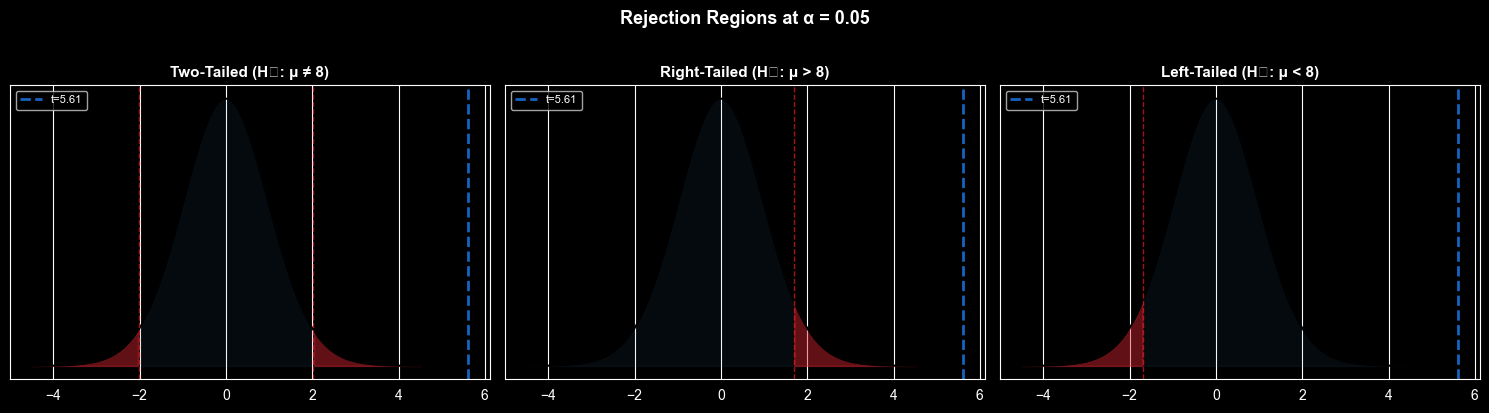

In [18]:
# Visualise rejection regions for all three tail types
df_val = len(battery_new_vendor) - 1
x = np.linspace(-4.5, 4.5, 400)
y = stats.t.pdf(x, df_val)
t_obs = stats.ttest_1samp(battery_new_vendor, 8.0).statistic

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_tail(axes[0], x, y, df_val, t_obs, 'two-sided', 'Two-Tailed (H₁: μ ≠ 8)')
plot_tail(axes[1], x, y, df_val, t_obs, 'greater',   'Right-Tailed (H₁: μ > 8)')
plot_tail(axes[2], x, y, df_val, t_obs, 'less',      'Left-Tailed (H₁: μ < 8)')
fig.suptitle('Rejection Regions at α = 0.05', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2b. Independent T-Test: `ttest_ind`

Two coaching centers prepare students for competitive exams. A parent wants to compare them. 35 students from each center — **different students** in each group.

In [19]:
# Two independent groups (different students)
np.random.seed(42)
center_a = np.random.normal(72, 12, 35)
center_b = np.random.normal(78, 12, 35)

# H0: mu_A = mu_B (no difference)
t_stat, p_value = stats.ttest_ind(center_a, center_b, alternative="greater")

print("=== INDEPENDENT T-TEST: Coaching Centers ===")
print(f"Center A: mean={np.mean(center_a):.1f}, n={len(center_a)}")
print(f"Center B: mean={np.mean(center_b):.1f}, n={len(center_b)}")
print(f"t-statistic:     {t_stat:.4f}")
print(f"P-value:         {p_value:.6f}")
print(f"Decision:        {'REJECT H0' if p_value < 0.05 else 'Fail to reject H0'}")

=== INDEPENDENT T-TEST: Coaching Centers ===
Center A: mean=70.4, n=35
Center B: mean=76.4, n=35
t-statistic:     -2.2891
P-value:         0.987406
Decision:        Fail to reject H0


### 2c. Paired T-Test: `ttest_rel`

A fitness app measures resting heart rate of 30 users **before and after** a 4-week program. The **same 30 people** are measured twice — this is paired data.

In [20]:
box("definition", "Definition: Paired T-Test",
    "Compares two measurements from the <b>same subjects</b>. Each 'before' value "
    "has a corresponding 'after' value from the same person. This test accounts for "
    "within-subject variability, making it more powerful than the independent t-test "
    "when the data is truly paired.")

In [21]:
# Same 30 users, measured before and after
np.random.seed(42)
before_hr = np.random.normal(75, 8, 30)
after_hr = before_hr - np.random.normal(3, 4, 30)

# H0: mean difference = 0 (no effect)
t_stat, p_value = stats.ttest_rel(before_hr, after_hr)

print("=== PAIRED T-TEST: Fitness Program ===")
print(f"Before: mean={np.mean(before_hr):.1f} bpm")
print(f"After:  mean={np.mean(after_hr):.1f} bpm")
print(f"Mean difference: {np.mean(before_hr - after_hr):.1f} bpm")
print(f"Paired t:        {t_stat:.4f}")
print(f"P-value:         {p_value:.6f}")
print(f"Decision:        {'REJECT H0' if p_value < 0.05 else 'Fail to reject H0'}")

=== PAIRED T-TEST: Fitness Program ===
Before: mean=73.5 bpm
After:  mean=71.0 bpm
Mean difference: 2.5 bpm
Paired t:        3.6991
P-value:         0.000900
Decision:        REJECT H0


### Common Mistake: Using `ttest_ind` on Paired Data

This is the most common t-test mistake. Using `ttest_ind` on before/after data from the **same** subjects ignores the within-subject correlation and **loses statistical power**.

In [22]:
# WRONG: treating paired data as independent
t_wrong, p_wrong = stats.ttest_ind(before_hr, after_hr)

# CORRECT: using the paired test
t_correct, p_correct = stats.ttest_rel(before_hr, after_hr)

print("=== WRONG vs CORRECT on Paired Data ===")
print(f"WRONG  (ttest_ind): t={t_wrong:.4f}, p={p_wrong:.6f}")
print(f"CORRECT (ttest_rel): t={t_correct:.4f}, p={p_correct:.6f}")
print()
print("The paired test has a SMALLER p-value.")
print("It has MORE POWER to detect the real effect.")

=== WRONG vs CORRECT on Paired Data ===
WRONG  (ttest_ind): t=1.3004, p=0.198623
CORRECT (ttest_rel): t=3.6991, p=0.000900

The paired test has a SMALLER p-value.
It has MORE POWER to detect the real effect.


In [23]:
box("danger", "Critical Error",
    "Using <code>ttest_ind</code> on paired data throws away within-subject "
    "information. This reduces statistical power — you may miss a real effect "
    "that <code>ttest_rel</code> would detect. <b>Decision rule:</b> Same subjects "
    "measured twice? Use <code>ttest_rel</code>. Different subjects? Use <code>ttest_ind</code>.")

### Exercise 1: Choose the Right T-Test

A school measures the reading speed of 25 students **before** and **after** a 6-week phonics program. The same students are tested both times. Complete the code below to run the correct test.

In [24]:
# Exercise 1: Choose the correct t-test
np.random.seed(100)
reading_before = np.random.normal(120, 20, 25)  # words per minute
reading_after = reading_before + np.random.normal(8, 10, 25)

# YOUR CODE HERE: choose the right test function
# t_stat, p_value = stats.????(reading_before, reading_after)
# print(f"t = {t_stat:.4f}, p = {p_value:.6f}")

In [25]:
# ---------- Self-Check (Run this cell to verify) ----------
t_stat, p_value = stats.ttest_rel(reading_before, reading_after)
assert p_value < 0.05, f"Expected significant result, got p={p_value:.4f}"
print(f"Correct! Paired t-test: t={t_stat:.4f}, p={p_value:.6f}")
print("ttest_rel is correct because the SAME students are tested twice.")

Correct! Paired t-test: t=-3.0262, p=0.005830
ttest_rel is correct because the SAME students are tested twice.


---

## Part 3: One-Way ANOVA

### The Judge Analogy

Imagine judging 3 chefs. Running multiple t-tests is like tasting Chef A vs B, then A vs C, then B vs C — each comparison with a 5% chance of a wrong call. By the third round, your overall error rate is 14.3%. ANOVA is like tasting all three dishes in a single round, keeping the error at 5%.

In [26]:
box("definition", "Definition: One-Way ANOVA",
    "Analysis of Variance (ANOVA) tests whether the means of <b>3 or more groups</b> "
    "are all equal. H0: all group means are equal. H1: at least one differs. "
    "Use <code>stats.f_oneway(group1, group2, group3)</code>.")

In [27]:
# Three regional offices: project completion times
np.random.seed(42)
bangalore = np.random.normal(45, 8, 50)
hyderabad = np.random.normal(42, 7, 50)
pune = np.random.normal(48, 9, 50)

# Why NOT 3 separate t-tests?
error_rate = 1 - 0.95**3
print(f"3 t-tests at alpha=0.05:")
print(f"P(at least 1 false positive) = {error_rate:.3f} = {error_rate*100:.1f}%")
print(f"Nearly TRIPLE the intended 5% error rate!")
print()

# ANOVA: correct approach
f_stat, p_value = stats.f_oneway(bangalore, hyderabad, pune)
print(f"ANOVA: F={f_stat:.4f}, p={p_value:.6f}")
print(f"Decision: {'At least one office differs' if p_value < 0.05 else 'No difference'}")

3 t-tests at alpha=0.05:
P(at least 1 false positive) = 0.143 = 14.3%
Nearly TRIPLE the intended 5% error rate!

ANOVA: F=7.2759, p=0.000970
Decision: At least one office differs


C:\Users\aloks\AppData\Local\Temp\ipykernel_34960\929150311.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


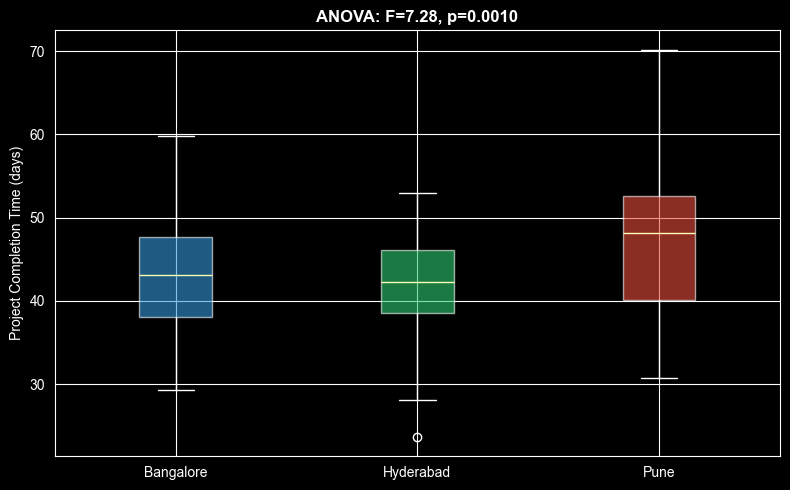

In [28]:
# Visualization: boxplots of the three offices
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [bangalore, hyderabad, pune],
    labels=['Bangalore', 'Hyderabad', 'Pune'],
    patch_artist=True
)
colors = ['#3498DB', '#2ECC71', '#E74C3C']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('Project Completion Time (days)')
ax.set_title(
    f'ANOVA: F={f_stat:.2f}, p={p_value:.4f}',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [29]:
box("tip", "Best Practice",
    "If ANOVA is significant, it tells you THAT a difference exists but not WHERE. "
    "Use a post-hoc test (e.g., Tukey HSD) to identify which specific pairs differ. "
    "Post-hoc tests are beyond this session — awareness only.")

---

## Part 4: Chi-Square Tests — Both Types

### 4a. Test of Independence: `chi2_contingency`

An online retailer wants to know if customer segment (Budget/Premium) is related to payment method (Cash/Card/UPI). Both variables are **categorical** — this calls for a chi-square test of independence.

In [30]:
box("definition", "Definition: Chi-Square Test of Independence",
    "Tests whether two <b>categorical</b> variables are related or independent. "
    "Input: a 2D contingency table of observed counts. "
    "H0: the variables are independent. H1: they are related.")

In [31]:
# Contingency table: segment x payment
observed = np.array([
    [120, 80, 100],    # Budget: Cash, Card, UPI
    [60, 140, 50],     # Premium: Cash, Card, UPI
])
segments = ['Budget', 'Premium']
payments = ['Cash', 'Card', 'UPI']

# Run test
chi2, p_value, dof, expected = stats.chi2_contingency(observed)

print("=== CHI-SQUARE INDEPENDENCE ===")
print("Observed:")
print(pd.DataFrame(observed, index=segments, columns=payments))
print(f"\nChi-square: {chi2:.4f}")
print(f"P-value:    {p_value:.6f}")
print(f"Expected:    {expected}")
print(f"Decision:   {'RELATED' if p_value < 0.05 else 'INDEPENDENT'}")

=== CHI-SQUARE INDEPENDENCE ===
Observed:
         Cash  Card  UPI
Budget    120    80  100
Premium    60   140   50

Chi-square: 48.8889
P-value:    0.000000
Expected:    [[ 98.18181818 120.          81.81818182]
 [ 81.81818182 100.          68.18181818]]
Decision:   RELATED


### 4b. Goodness of Fit: `chisquare`

A board game company claims their dice are fair. A customer rolls one die 600 times. Does the distribution match a fair die (100 expected per face)?

In [32]:
box("definition", "Definition: Chi-Square Goodness of Fit",
    "Tests whether an <b>observed</b> frequency distribution matches an "
    "<b>expected</b> distribution. Input: two 1D arrays of counts. "
    "H0: observed matches expected. H1: they differ.")

In [33]:
# Observed die rolls (600 total)
observed_rolls = np.array([110, 95, 105, 90, 100, 100])
expected_rolls = np.array([100, 100, 100, 100, 100, 100])

chi2, p_value = stats.chisquare(observed_rolls, f_exp=expected_rolls)

print("=== CHI-SQUARE GOODNESS OF FIT ===")
print(f"Observed: {observed_rolls}")
print(f"Expected: {expected_rolls}")
print(f"Chi-square: {chi2:.4f}")
print(f"P-value:    {p_value:.6f}")
print(f"Decision:   {'NOT fair' if p_value < 0.05 else 'No evidence die is unfair'}")

=== CHI-SQUARE GOODNESS OF FIT ===
Observed: [110  95 105  90 100 100]
Expected: [100 100 100 100 100 100]
Chi-square: 2.5000
P-value:    0.776495
Decision:   No evidence die is unfair


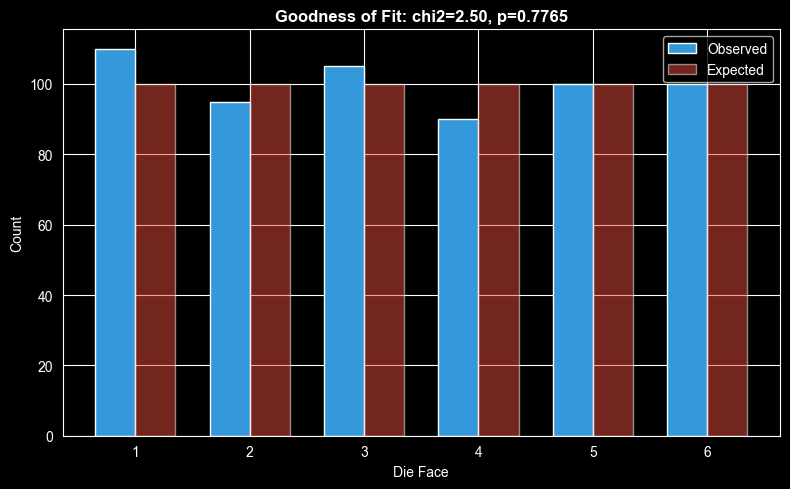

In [34]:
# Visualization: observed vs expected
faces = ['1', '2', '3', '4', '5', '6']
x = np.arange(len(faces))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, observed_rolls, width, label='Observed', color='#3498DB')
ax.bar(x + width/2, expected_rolls, width, label='Expected', color='#E74C3C', alpha=0.5)
ax.set_xlabel('Die Face')
ax.set_ylabel('Count')
ax.set_title(f'Goodness of Fit: chi2={chi2:.2f}, p={p_value:.4f}', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(faces)
ax.legend()
plt.tight_layout()
plt.show()

### Chi-Square Comparison

| | Independence | Goodness of Fit |
|---|---|---|
| **Function** | `chi2_contingency(table)` | `chisquare(obs, f_exp=exp)` |
| **Question** | Are 2 categorical variables related? | Does observed match expected? |
| **Input** | 2D contingency table | Two 1D count arrays |

---

## Part 5: Correlation vs Causation (Brief)



**One rule:** Correlation does NOT imply causation.

- Ice cream sales and drowning deaths both increase in summer — the confounding variable is **temperature**
- Three threats: confounders, reverse causation, coincidence
- Only **randomized controlled experiments** (like A/B tests) establish causation
- Every statistical test in this notebook measures **association**, not causation

---

## Part 6: Type I and Type II Errors — Diabetes Screening

### The Smoke Detector Analogy

A **sensitive** smoke detector catches every fire (few Type II errors) but goes off when you burn toast (many Type I errors). A **strict** detector never gives false alarms (few Type I) but might miss a slow-burning fire (more Type II). You choose sensitivity based on which error is more dangerous. For fires, you tolerate false alarms to avoid missing a real one.

In [35]:
box("definition", "Definition: Type I and Type II Errors",
    "<b>Type I Error (False Positive):</b> Rejecting H0 when it is true. "
    "'The test says diabetes but the patient is healthy.' Probability = &alpha;.<br>"
    "<b>Type II Error (False Negative):</b> Failing to reject H0 when it is false. "
    "'The test says healthy but the patient has diabetes.' Probability = &beta;.")

### The Diabetes Screening Scenario

A hospital screens 1000 patients for diabetes using a blood glucose test.
- 200 patients actually have diabetes, 800 are healthy
- The test uses a threshold: if glucose > 140 mg/dL, the test flags "Diabetes"

| | Actually Diabetic | Actually Healthy |
|---|---|---|
| **Test: "Diabetes"** | True Positive (TP) | <font color="#c62828"><b>False Positive (Type I)</b></font> |
| **Test: "Healthy"** | <font color="#c62828"><b>False Negative (Type II)</b></font> | True Negative (TN) |

In [36]:
# Simulate blood glucose levels
np.random.seed(42)
n_diabetic = 200
n_healthy = 800

# Diabetic: higher glucose; Healthy: normal glucose
diabetic_glucose = np.random.normal(180, 40, n_diabetic)
healthy_glucose = np.random.normal(100, 25, n_healthy)

# Screening threshold
threshold = 140

# Classify each patient
tp = np.sum(diabetic_glucose > threshold)   # correctly detected
fn = np.sum(diabetic_glucose <= threshold)   # MISSED (Type II)
fp = np.sum(healthy_glucose > threshold)     # false alarm (Type I)
tn = np.sum(healthy_glucose <= threshold)    # correctly cleared

print("=== DIABETES SCREENING RESULTS ===")
print(f"Threshold: {threshold} mg/dL")
print(f"True Positives:  {tp:3d} (detected diabetes)")
print(f"False Negatives: {fn:3d} (MISSED diabetes - Type II)")
print(f"False Positives: {fp:3d} (false alarm - Type I)")
print(f"True Negatives:  {tn:3d} (correctly healthy)")
print(f"\nSensitivity: {tp/(tp+fn):.1%}")
print(f"Specificity: {tn/(tn+fp):.1%}")

=== DIABETES SCREENING RESULTS ===
Threshold: 140 mg/dL
True Positives:  168 (detected diabetes)
False Negatives:  32 (MISSED diabetes - Type II)
False Positives:  49 (false alarm - Type I)
True Negatives:  751 (correctly healthy)

Sensitivity: 84.0%
Specificity: 93.9%


In [37]:
box("output", "Output Explanation",
    f"Sensitivity = {tp/(tp+fn):.1%} means the test catches {tp/(tp+fn):.1%} of diabetic patients. "
    f"Specificity = {tn/(tn+fp):.1%} means {tn/(tn+fp):.1%} of healthy patients are correctly cleared. "
    f"The {fn} false negatives are the most dangerous — {fn} diabetic patients told they are healthy.")

### The Threshold Tradeoff

Lowering the threshold catches more diabetic patients (fewer FN) but flags more healthy ones (more FP). This is always a tradeoff — you cannot minimize both error types simultaneously.

In [38]:
# How threshold changes the tradeoff
thresholds = [120, 130, 140, 150, 160]

print("=== THRESHOLD TRADEOFF ===")
print(f"{'Thresh':>6} {'TP':>4} {'FN':>4} {'FP':>4} {'TN':>4} {'Sens':>8} {'Spec':>8}")
print("-" * 50)

for t in thresholds:
    tp_t = np.sum(diabetic_glucose > t)
    fn_t = np.sum(diabetic_glucose <= t)
    fp_t = np.sum(healthy_glucose > t)
    tn_t = np.sum(healthy_glucose <= t)
    sens = tp_t / (tp_t + fn_t)
    spec = tn_t / (tn_t + fp_t)
    print(f"{t:>6} {tp_t:>4} {fn_t:>4} {fp_t:>4} {tn_t:>4} {sens:>7.1%} {spec:>7.1%}")

=== THRESHOLD TRADEOFF ===
Thresh   TP   FN   FP   TN     Sens     Spec
--------------------------------------------------
   120  190   10  168  632   95.0%   79.0%
   130  182   18   93  707   91.0%   88.4%
   140  168   32   49  751   84.0%   93.9%
   150  152   48   21  779   76.0%   97.4%
   160  137   63    8  792   68.5%   99.0%


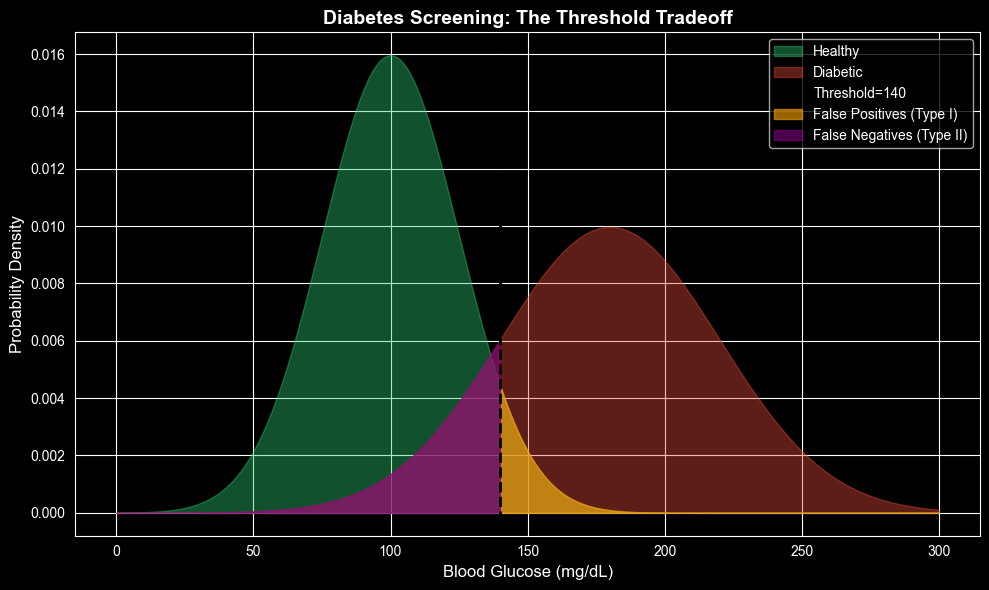

In [39]:
# Visualization: overlapping distributions with threshold
fig, ax = plt.subplots(figsize=(10, 6))

x_range = np.linspace(0, 300, 1000)
healthy_dist = stats.norm.pdf(x_range, 100, 25)
diabetic_dist = stats.norm.pdf(x_range, 180, 40)

# Plot distributions
ax.fill_between(x_range, healthy_dist, alpha=0.4, color='#2ECC71', label='Healthy')
ax.fill_between(x_range, diabetic_dist, alpha=0.4, color='#E74C3C', label='Diabetic')
ax.axvline(x=threshold, color='black', ls='--', lw=2, label=f'Threshold={threshold}')

# Shade error regions
mask_fp = x_range > threshold
ax.fill_between(x_range[mask_fp], healthy_dist[mask_fp], alpha=0.6,
                color='orange', label='False Positives (Type I)')
mask_fn = x_range < threshold
ax.fill_between(x_range[mask_fn], diabetic_dist[mask_fn], alpha=0.6,
                color='purple', label='False Negatives (Type II)')

ax.set_xlabel('Blood Glucose (mg/dL)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Diabetes Screening: The Threshold Tradeoff', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [40]:
box("warning", "Key Insight",
    "Lower threshold = more TP, fewer FN, but MORE FP. "
    "Higher threshold = fewer FP, more TN, but MORE FN. "
    "You <b>cannot</b> minimize both errors simultaneously. "
    "In medical screening, missing a disease (Type II) is worse than a false alarm (Type I).")

---

## Capstone Mini-Project: HR Analytics Test Selector

**Company:** TechIndia Solutions — an Indian IT company with 3 departments (Engineering, Marketing, Sales).

**Task:** For each research question below, identify the correct test, run it, and interpret the result.

In [41]:
print("=" * 60)
print("MINI-PROJECT: HR Analytics Test Selector")
print("=" * 60)

np.random.seed(42)

# --- Q1: Z-TEST ---
print("\n--- Q1: Is avg salary = Rs.60,000? (sigma known = Rs.12,000) ---")
salaries = np.random.normal(58000, 12000, 100)
z = (np.mean(salaries) - 60000) / (12000 / np.sqrt(100))
p = 2 * stats.norm.sf(abs(z))
print(f"Test: Z-test (sigma known)")
print(f"z = {z:.4f}, p = {p:.4f}")

# --- Q2: ONE-SAMPLE T-TEST ---
print("\n--- Q2: Is avg hours worked = 40/week? (sigma unknown) ---")
hours = np.random.normal(42, 5, 50)
t, p = stats.ttest_1samp(hours, 40)
print(f"Test: One-sample t-test")
print(f"t = {t:.4f}, p = {p:.4f}")

# --- Q3: PAIRED T-TEST ---
print("\n--- Q3: Did WFH policy improve satisfaction? (same employees) ---")
before_sat = np.random.normal(6.5, 1.5, 40)
after_sat = before_sat + np.random.normal(0.8, 1.0, 40)
t, p = stats.ttest_rel(before_sat, after_sat)
print(f"Test: Paired t-test")
print(f"t = {t:.4f}, p = {p:.4f}")

# --- Q4: ANOVA ---
print("\n--- Q4: Do 3 departments differ in productivity? ---")
eng = np.random.normal(78, 10, 40)
mkt = np.random.normal(72, 12, 40)
sales_dept = np.random.normal(75, 11, 40)
f, p = stats.f_oneway(eng, mkt, sales_dept)
print(f"Test: One-way ANOVA")
print(f"F = {f:.4f}, p = {p:.4f}")

# --- Q5: CHI-SQUARE INDEPENDENCE ---
print("\n--- Q5: Is department related to attrition? ---")
attrition = np.array([[30, 70], [20, 80], [35, 65]])
chi2, p, dof, _ = stats.chi2_contingency(attrition)
print(f"Test: Chi-square independence")
print(f"chi2 = {chi2:.4f}, p = {p:.4f}")

# --- Q6: CHI-SQUARE GOODNESS OF FIT ---
print("\n--- Q6: Does hiring match target 40:35:25? ---")
obs_hires = np.array([48, 30, 22])
exp_hires = np.array([40, 35, 25])
chi2, p = stats.chisquare(obs_hires, f_exp=exp_hires)
print(f"Test: Chi-square goodness of fit")
print(f"chi2 = {chi2:.4f}, p = {p:.4f}")

MINI-PROJECT: HR Analytics Test Selector

--- Q1: Is avg salary = Rs.60,000? (sigma known = Rs.12,000) ---
Test: Z-test (sigma known)
z = -2.7051, p = 0.0068

--- Q2: Is avg hours worked = 40/week? (sigma unknown) ---
Test: One-sample t-test
t = 2.5119, p = 0.0154

--- Q3: Did WFH policy improve satisfaction? (same employees) ---
Test: Paired t-test
t = -5.5391, p = 0.0000

--- Q4: Do 3 departments differ in productivity? ---
Test: One-way ANOVA
F = 1.2660, p = 0.2858

--- Q5: Is department related to attrition? ---
Test: Chi-square independence
chi2 = 5.7456, p = 0.0565

--- Q6: Does hiring match target 40:35:25? ---
Test: Chi-square goodness of fit
chi2 = 2.6743, p = 0.2626


In [42]:
# Summary table
print("\n" + "=" * 60)
print("TEST SELECTION SUMMARY")
print("=" * 60)
tests = [
    ("Sample mean vs value (sigma known)", "Z-test"),
    ("Sample mean vs value (sigma unknown)", "One-sample t-test"),
    ("Same subjects before/after", "Paired t-test"),
    ("3+ independent groups", "One-way ANOVA"),
    ("2 categorical variables", "Chi-sq independence"),
    ("Observed vs expected distribution", "Chi-sq goodness of fit"),
]
for question, test in tests:
    print(f"  {question:<42} {test}")
print("=" * 60)


TEST SELECTION SUMMARY
  Sample mean vs value (sigma known)         Z-test
  Sample mean vs value (sigma unknown)       One-sample t-test
  Same subjects before/after                 Paired t-test
  3+ independent groups                      One-way ANOVA
  2 categorical variables                    Chi-sq independence
  Observed vs expected distribution          Chi-sq goodness of fit


---

## Summary and Key Takeaways

1. **Z-test:** Requires known sigma — rare in practice. Default to t-test.
2. **T-test family:** `ttest_1samp` (vs value), `ttest_ind` (different groups), `ttest_rel` (same subjects)
3. **Anti-pattern:** Using `ttest_ind` on paired data loses statistical power
4. **ANOVA:** Compares 3+ groups at the correct error rate
5. **Chi-square:** `chi2_contingency` (independence, 2D) vs `chisquare` (goodness of fit, 1D)
6. **Type I Error (FP):** Rejecting true H0 | **Type II Error (FN):** Missing a real effect
7. **The tradeoff:** Cannot minimize both errors simultaneously

**Next session:** Introduction to sklearn — your FIRST machine learning model!

---

## Further Reading

- **SciPy Statistics Module:** https://docs.scipy.org/doc/scipy/reference/stats.html
- **Khan Academy — Hypothesis Testing:** https://www.khanacademy.org/math/statistics-probability/significance-tests-one-sample

---

*Vishlesan i-Hub IIT Patna × Masai School*